# CSR: Docker results K6 benchmark

The k6 benchmark ran twice (5.000VUs and 10.000VUs per minute) for 21 minutes. The goal was to show the performance of the setup under average load. 

Every 5 seconds, the docker statistics (CPU and memory usage per container) were gathered and logged.

In [5]:
import pandas as pd;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import math

plt.rcParams.update({'font.size': 14})
pd.set_option('display.float_format', lambda x: '%.2f' % x)
path = '../../../../k6/results/csr/'

def convert_to_MiB(value):
    if 'GiB' in value:
        return str(int(float(value.replace('GiB', '')) * 1024))
    if 'MiB' in value:
        return value.replace('MiB', '')
    if 'B' in value:
        return str(int(float(value.replace('B', '')) / 1024))
    return value

def detect_outliers(df, features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(df[features])
    return outliers == 1

def graph_row(plot_func, dataset, features, height=4, width=20):
    cols = len(features)
    fig, axes = plt.subplots(ncols=cols, figsize=(width, height))
    plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
    for x, f in enumerate(features):
        plot_func(dataset, f, axes[x], idx=x)
    return plt

def graph_grid(plot_func, dataset, features, height=4, width=20, cols=2):
    fig, axes = plt.subplots(ncols=cols, nrows=math.ceil(len(features) / cols), figsize=(width, height))
    plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
    axes = axes.flatten()  
    for x, f in enumerate(features):
        plot_func(dataset, f, axes[x], idx=x)
    return plt

services = ["monolith", "cdn", "discovery"]

# Test: 10.000 VUs (+ outlier removal on K6 metrics)

In [6]:
dirty_df = pd.read_csv(f'{path}10000/metrics.csv', sep=',')

duration = ['duration_mean', 'duration_min', 'duration_max', 'duration_count']
throughput = ['throughput_mean', 'throughput_min', 'throughput_max', 'throughput_count']
err = ['err_mean', 'err_count']

dirty_df = dirty_df[dirty_df['timestamp'] >= 30].dropna(subset=[*duration, *throughput]).reset_index(drop=True)

mask = detect_outliers(dirty_df, [*duration, *throughput])
df_10000 = dirty_df[mask].copy().reset_index(drop=True)

# Test: 5.000 VUs  (+ outlier removal on K6 metrics)

In [7]:
dirty_df = pd.read_csv(f'{path}5000/metrics.csv', sep=',')

duration = ['duration_mean', 'duration_min', 'duration_max', 'duration_count']
throughput = ['throughput_mean', 'throughput_min', 'throughput_max', 'throughput_count']
err = ['err_mean', 'err_count']

dirty_df = dirty_df[dirty_df['timestamp'] >= 30].dropna(subset=[*duration, *throughput]).reset_index(drop=True)

mask = detect_outliers(dirty_df, [*duration, *throughput])
df_5000 = dirty_df[mask].copy().reset_index(drop=True)

# CPU Usage    5.000 vs 10.000

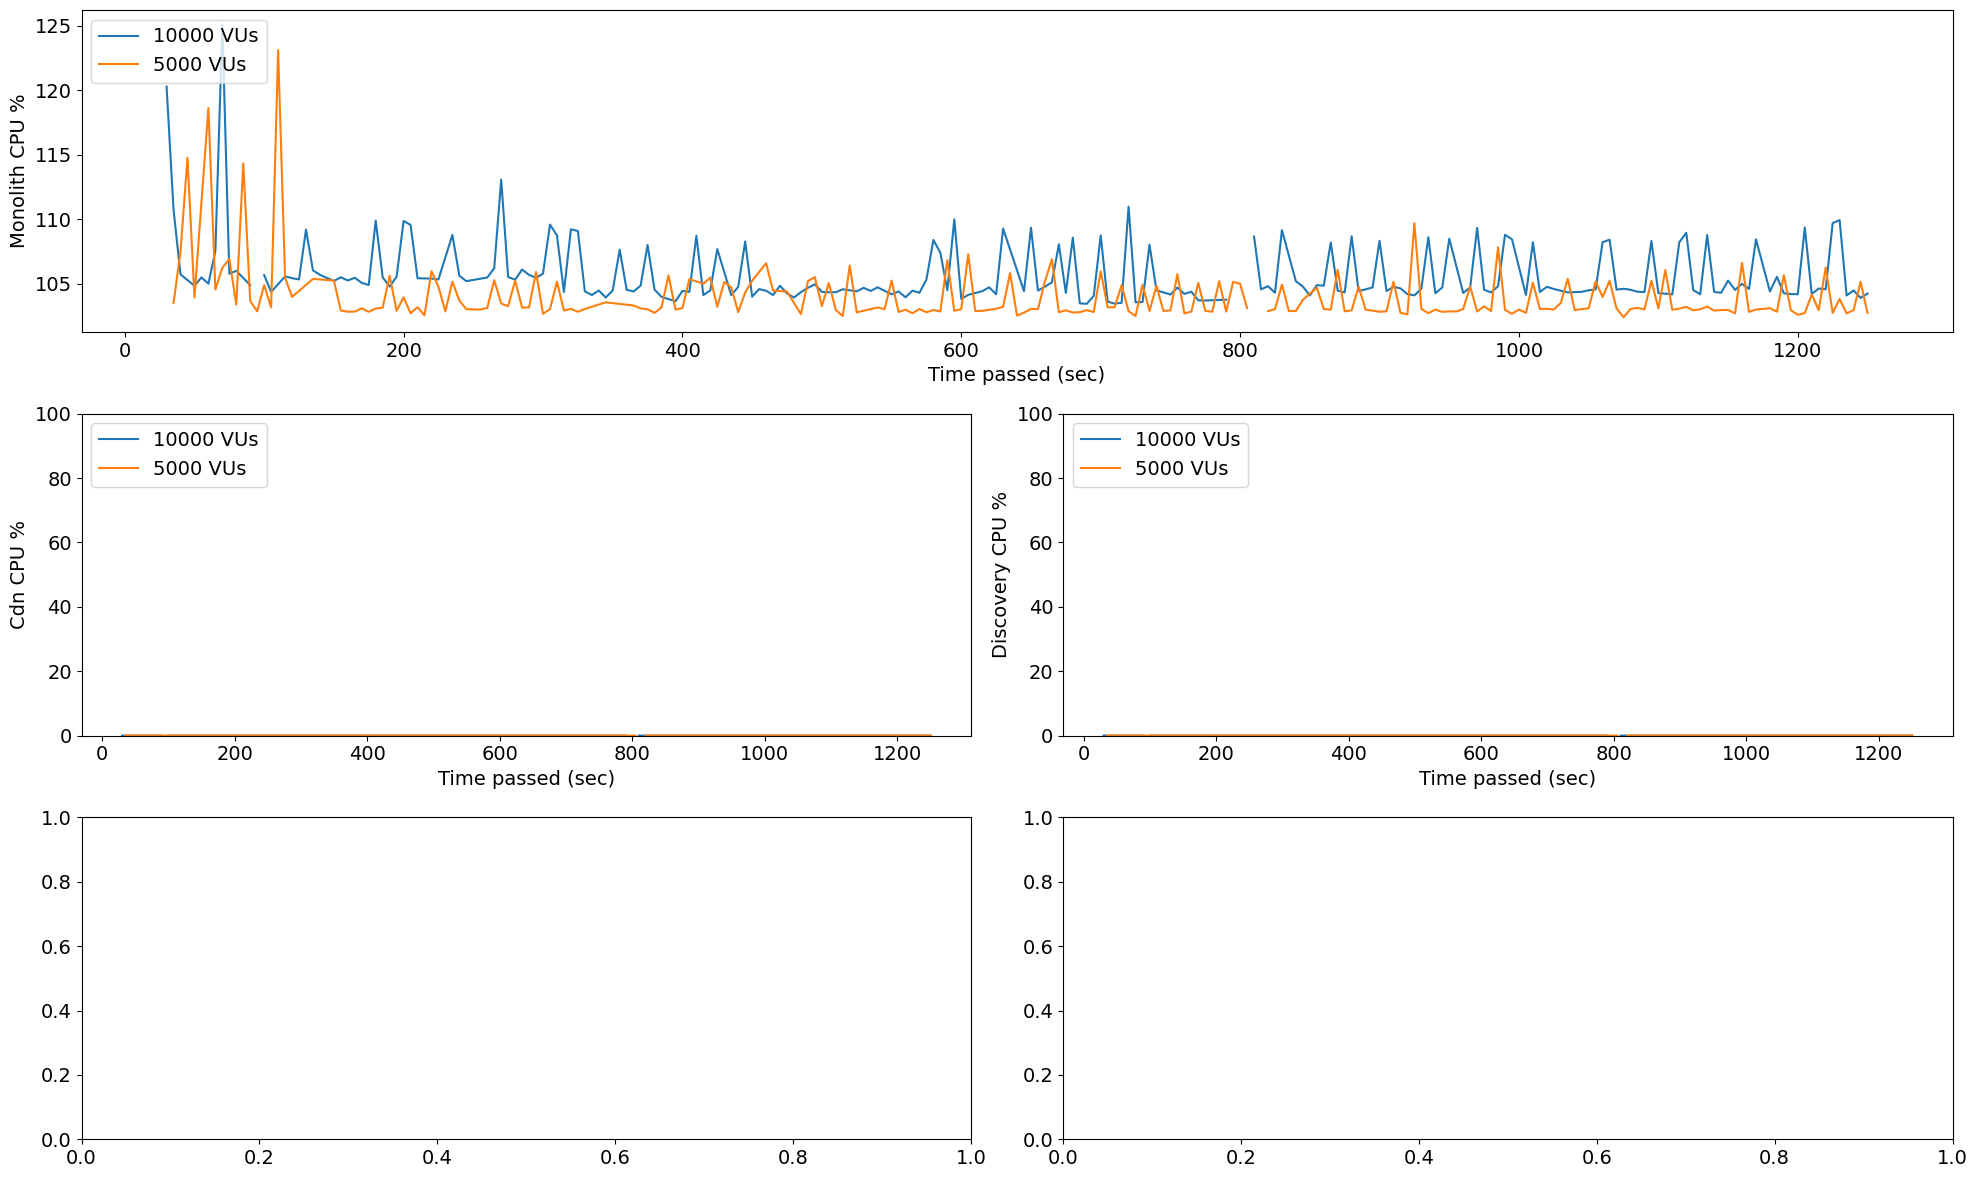

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 12))
gs = axes[0, 0].get_gridspec()

for ax in axes[0, :]:
    ax.remove()

axbig = fig.add_subplot(gs[0, :])

axes = axes[1:, :].flatten()

axbig.plot(df_10000['timestamp'], df_10000[f'{services[0]}_cpu_percent'], label='10000 VUs')
axbig.plot(df_5000['timestamp'], df_5000[f'{services[0]}_cpu_percent'], label='5000 VUs')
axbig.set_xlabel('Time passed (sec)')
axbig.set_ylabel(f'{services[0].capitalize()} CPU %')
axbig.legend(loc="upper left")

for ax, s in zip(axes, services[1:]):
    ax.plot(df_10000['timestamp'], df_10000[f'{s}_cpu_percent'], label='10000 VUs')
    ax.plot(df_5000['timestamp'], df_5000[f'{s}_cpu_percent'], label='5000 VUs')
    ax.set_xlabel('Time passed (sec)')
    ax.set_ylabel(f'{s.capitalize()} CPU %')
    ax.legend(loc="upper left")
    ax.set_ylim(bottom=0, top=100)

plt.tight_layout()
plt.show()

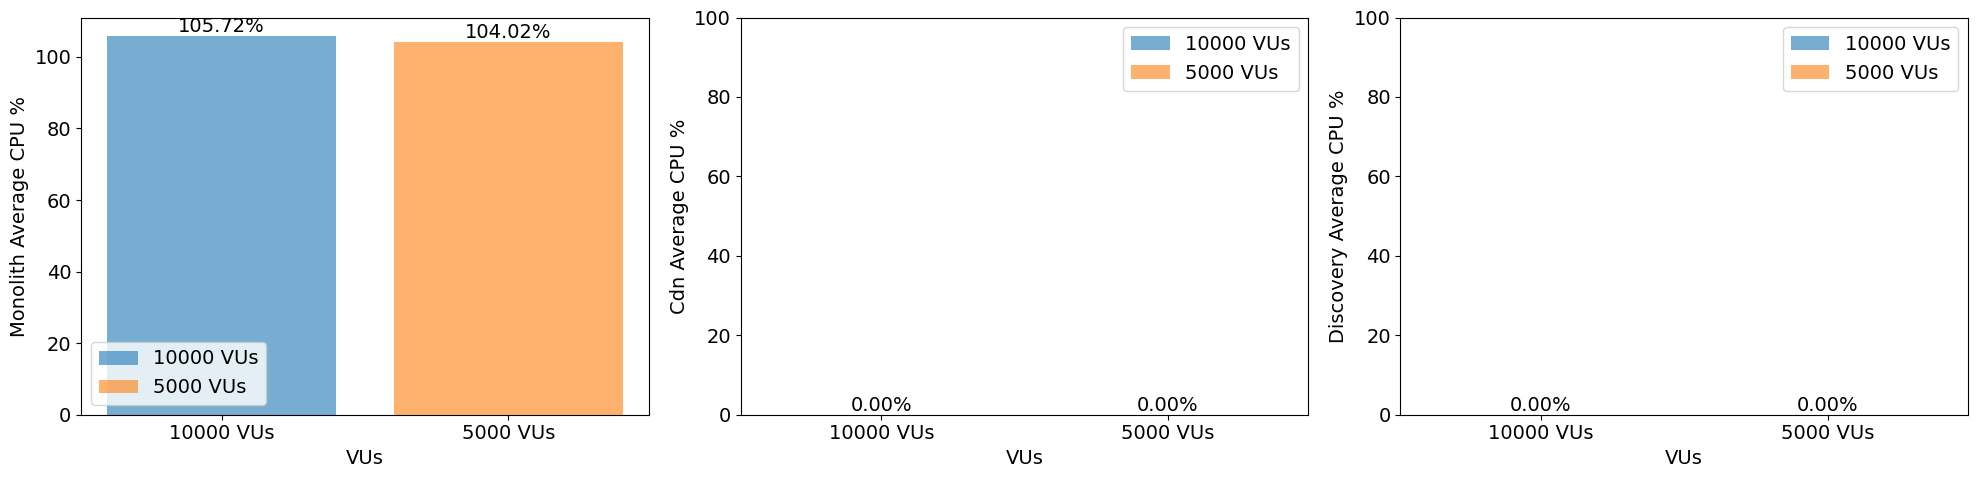

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=len(services), figsize=(20, 5))

for i, s in enumerate(services):
    bars_10000 = axes[i].bar('10000 VUs', df_10000[f'{s}_cpu_percent'].mean(), label=f'10000 VUs', alpha=0.6)
    bars_5000 = axes[i].bar('5000 VUs', df_5000[f'{s}_cpu_percent'].mean(), label=f'5000 VUs', alpha=0.6)

    axes[i].set_xlabel('VUs')
    axes[i].set_ylabel(f'{s.capitalize()} Average CPU %')
    axes[i].legend()
    if(i != 0):
        axes[i].set_ylim(bottom=0, top=100)

    for bar in bars_10000:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom')
    
    for bar in bars_5000:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Memory usage 10.000 vs 5.000

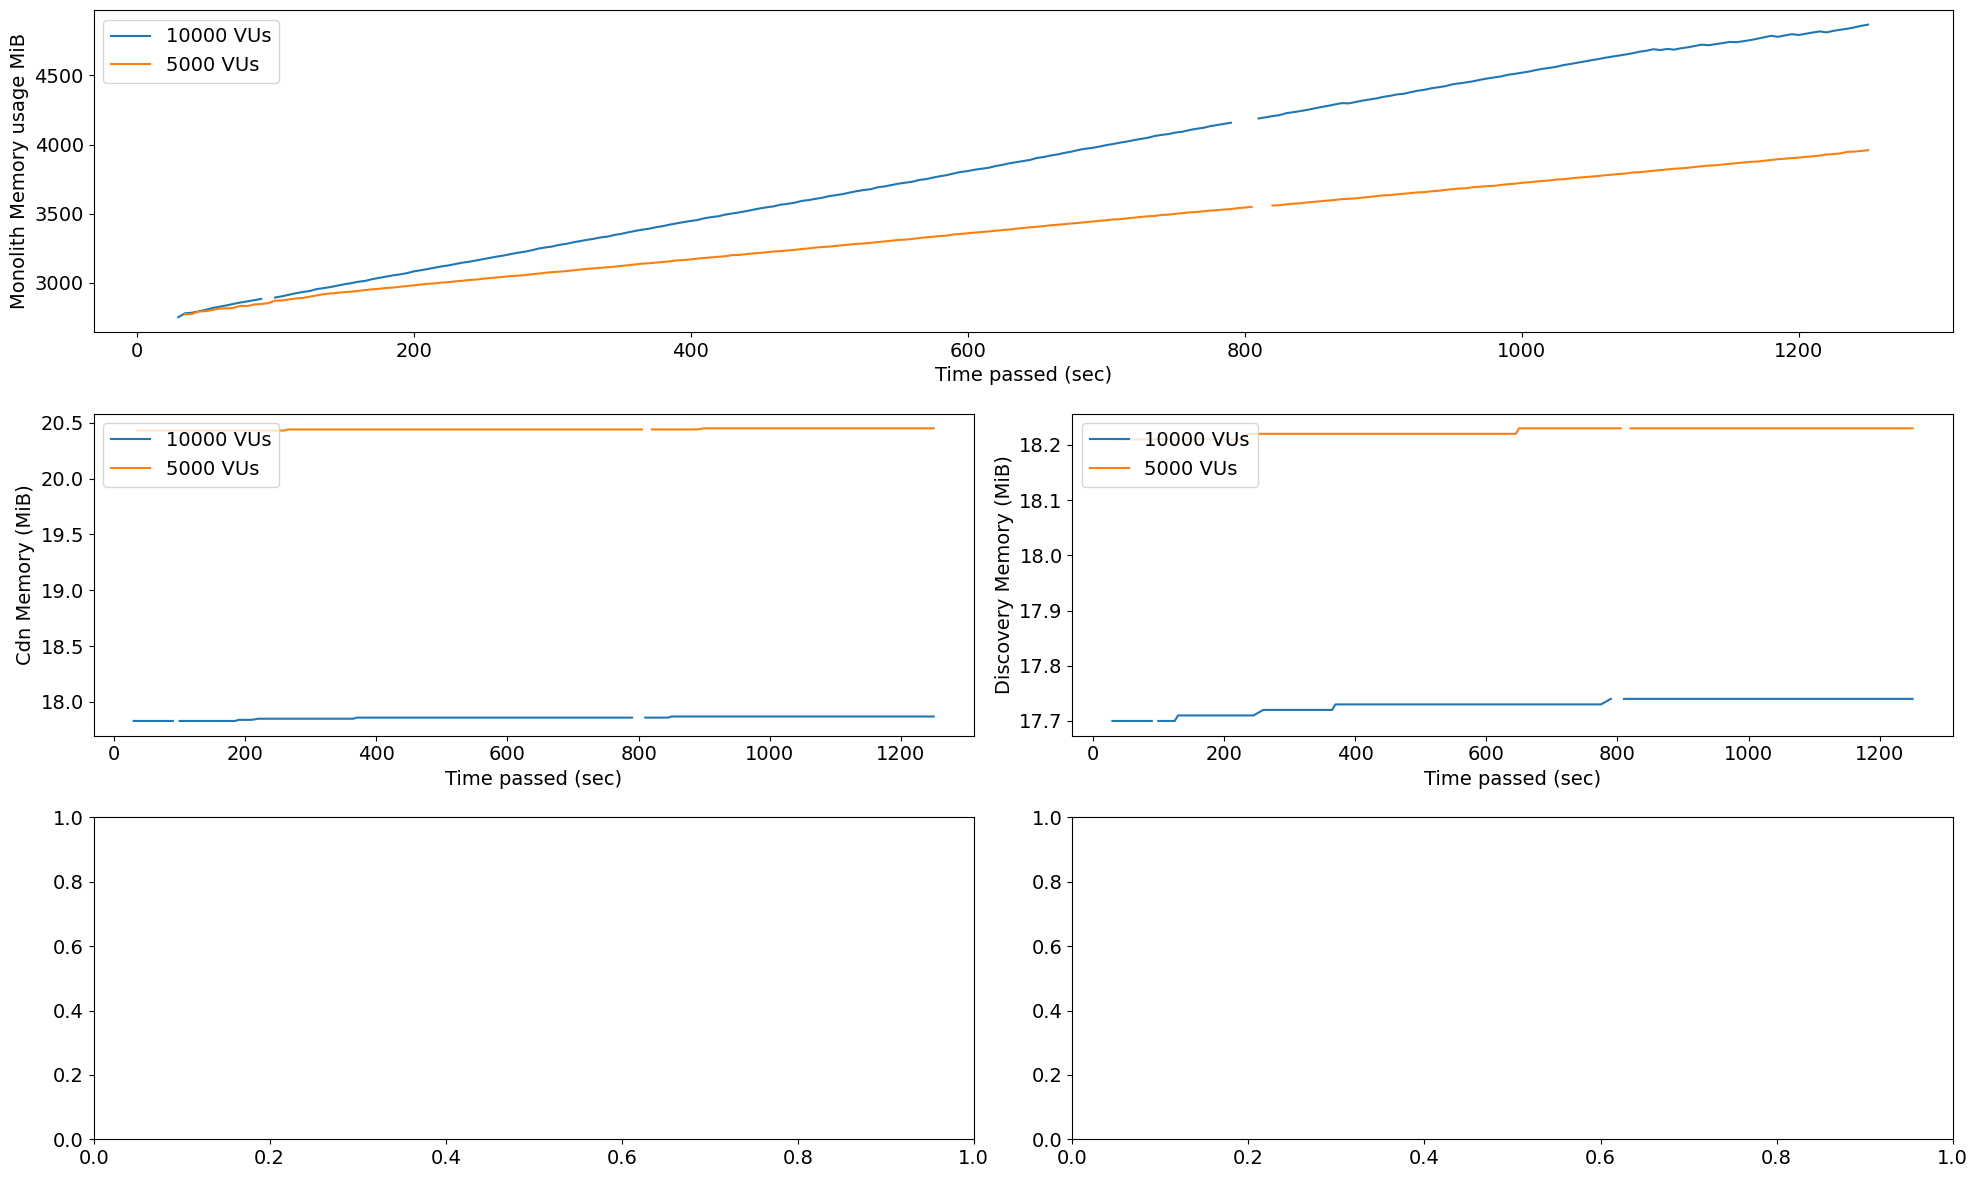

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 12))
gs = axes[0, 0].get_gridspec()

for ax in axes[0, :]:
    ax.remove()

axbig = fig.add_subplot(gs[0, :])

axes = axes[1:, :].flatten()

axbig.plot(df_10000['timestamp'], df_10000[f'{services[0]}_mem_usage'], label='10000 VUs')
axbig.plot(df_5000['timestamp'], df_5000[f'{services[0]}_mem_usage'], label='5000 VUs')
axbig.set_xlabel('Time passed (sec)')
axbig.set_ylabel(f'{services[0].capitalize()} Memory usage MiB')
axbig.legend(loc="upper left")

for ax, s in zip(axes, services[1:]):
    ax.plot(df_10000['timestamp'], df_10000[f'{s}_mem_usage'], label='10000 VUs')
    ax.plot(df_5000['timestamp'], df_5000[f'{s}_mem_usage'], label='5000 VUs')
    ax.set_xlabel('Time passed (sec)')
    ax.set_ylabel(f'{s.capitalize()} Memory (MiB)')
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

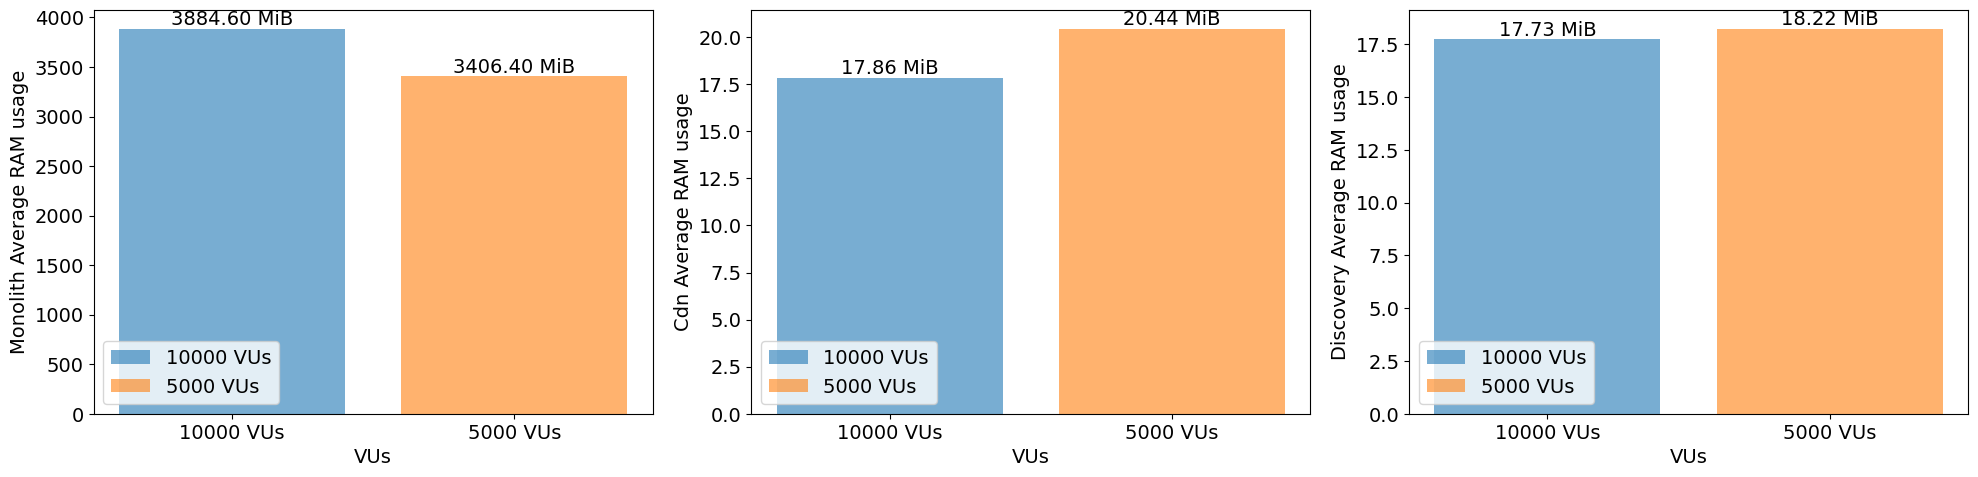

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=len(services), figsize=(20, 5))

for i, s in enumerate(services):
    bars_10000 = axes[i].bar('10000 VUs', df_10000[f'{s}_mem_usage'].mean(), label=f'10000 VUs', alpha=0.6)
    bars_5000 = axes[i].bar('5000 VUs', df_5000[f'{s}_mem_usage'].mean(), label=f'5000 VUs', alpha=0.6)

    axes[i].set_xlabel('VUs')
    axes[i].set_ylabel(f'{s.capitalize()} Average RAM usage')
    axes[i].legend(loc='lower left')

    for bar in bars_10000:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f} MiB', ha='center', va='bottom')
    
    for bar in bars_5000:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f} MiB', ha='center', va='bottom')


plt.tight_layout()
plt.show()